In [8]:
import sys

sys.path.append("..")
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from numbers import Number
from qiskit.synthesis import LieTrotter
import numpy as np
import scipy as scipy
import matplotlib.pyplot as plt

### Try MPF for the trotter evolution (?)

In [ ]:
# import os
# #TOKEN = os.getenv("TOKEN")
# #service = QiskitRuntimeService(token=TOKEN,channel='ibm_quantum', instance="pinq-quebec-hub/sustainability-w/main")
# service=QiskitRuntimeService(instance="client-enablement/solutions/demo-testing")
# backend = service.backend("ibm_torino")

# # qubit_subset = [4, 5, 6, 7, 8, 16, 17, 23, 24, 25, 26, 27]  # trying 1 loop for torino
# # remap = {q: i for q, i in zip(qubit_subset, range(len(qubit_subset)))}
# # rev_map = {val: key for key, val in remap.items()}

# qubit_subset = list(range(21))

# # cm = backend.coupling_map
# # reduced_map = cm.reduce(qubit_subset)
# # edge_list = {(a, b) if a < b else (b, a) for a, b in list(reduced_map.get_edges())}
# # ent_dec = [(rev_map[i], rev_map[j]) for i, j in edge_list]

# ent_map = [(i,i+1) for i in range(19)]
# ent_map+=[(19,0)]

# def Heisenberg(J, n, ent_map):
#     if isinstance(J, Number):
#         J = np.ones(len(ent_map)) * J
#     else:
#         assert len(J) == len(ent_map)
#     String = "I" * n
#     H = SparsePauliOp("I" * n, 0)
#     for j, c in zip(J, ent_map):
#         c = np.sort(c)
#         XX = String[: c[0]] + "X" + String[c[0] + 1 : c[1]] + "X" + String[c[1] + 1 :]
#         H += SparsePauliOp(XX, j)
#         YY = String[: c[0]] + "Y" + String[c[0] + 1 : c[1]] + "Y" + String[c[1] + 1 :]
#         H += SparsePauliOp(YY, j)
#         ZZ = String[: c[0]] + "Z" + String[c[0] + 1 : c[1]] + "Z" + String[c[1] + 1 :]
#         H += SparsePauliOp(ZZ, j)
#     return H.chop()


# H = Heisenberg(1, 21, ent_map)

### State preparation with 1 ancilla and 2 excitations

In [682]:
def prep_psi_0(qc: QuantumCircuit):
    qc.cx(20, 4)
    qc.cx(20, 14)
    return qc


def prep_psi_0_by_0(qc: QuantumCircuit):
    qc.cx(20, 4, ctrl_state="0")
    qc.cx(20, 14, ctrl_state="0")
    return qc

### Test if state prep works as expected

In [683]:
from qiskit_aer import StatevectorSimulator

sv = StatevectorSimulator()
qc = QuantumCircuit(21)
qc.h(20)
# qc.cx(21,4)
# qc.cx(20,22)
# qc.cx(13,14)
qc = prep_psi_0(qc)

job = sv.run(circuits=qc)
res = job.result()

res.get_counts()

{np.str_('000000000000000000000'): np.float64(0.5),
 np.str_('100000100000000010000'): np.float64(0.5)}

In [684]:
qc = prep_psi_0_by_0(qc)
job = sv.run(circuits=qc)
res = job.result()

res.get_counts()

{np.str_('000000100000000010000'): np.float64(0.5),
 np.str_('100000100000000010000'): np.float64(0.5)}

## Hardware experiments

In [924]:
from qiskit.transpiler import generate_preset_pass_manager

t_steps = 8
num_qubits = 20
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
H_tilde = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde = np.zeros([t_steps, t_steps], dtype=complex)
delta_t = np.pi / 40
synth = LieTrotter(reps=1)

# ent_map = [(i,i+1) for i in range(0,19)]
# ent_map+=[(19,0)]

qubit_subset = list(range(25, 34)) + list(range(44, 53)) + [35, 37]
remap = {q: i for q, i in zip(qubit_subset, range(len(qubit_subset)))}
rev_map = {val: key for key, val in remap.items()}


cm = backend.coupling_map
reduced_map = cm.reduce(qubit_subset)
edge_list = {(a, b) if a < b else (b, a) for a, b in list(reduced_map.get_edges())}
ent_dec = [(rev_map[i], rev_map[j]) for i, j in edge_list]


def Heisenberg(J, n, ent_map):
    if isinstance(J, Number):
        J = np.ones(len(ent_map)) * J
    else:
        assert len(J) == len(ent_map)
    String = "I" * n
    H = SparsePauliOp("I" * n, 0)
    for j, c in zip(J, ent_map):
        c = np.sort(c)
        XX = String[: c[0]] + "X" + String[c[0] + 1 : c[1]] + "X" + String[c[1] + 1 :]
        H += SparsePauliOp(XX, j)
        YY = String[: c[0]] + "Y" + String[c[0] + 1 : c[1]] + "Y" + String[c[1] + 1 :]
        H += SparsePauliOp(YY, j)
        ZZ = String[: c[0]] + "Z" + String[c[0] + 1 : c[1]] + "Z" + String[c[1] + 1 :]
        H += SparsePauliOp(ZZ, j)
    return H.chop()


H = Heisenberg(1, num_qubits, edge_list)

# Generate approximate time evolution, rather than using PauliEvolutionGate
Rxyz_circ = QuantumCircuit(2)
Rxyz_circ.rxx(2 * delta_t, 0, 1)
Rxyz_circ.ryy(2 * delta_t, 0, 1)
Rxyz_circ.rzz(2 * delta_t, 0, 1)
Rxyz_instr = Rxyz_circ.to_instruction(label="RXX+YY+ZZ")
qc_temp = QuantumCircuit(num_qubits)
for edge in edge_list:
    qc_temp.append(Rxyz_instr, edge)
time_evol = QuantumCircuit(num_qubits).compose(qc_temp)

# time_evol=PauliEvolutionGate(H,time=delta_t,synthesis=synth)
real_obs_H = SparsePauliOp("X", 1) ^ H
imag_obs_H = SparsePauliOp("Y", 1) ^ H
real_obs_S = SparsePauliOp("X", 1) ^ SparsePauliOp("I" * 20, 1)
imag_obs_S = SparsePauliOp("Y", 1) ^ SparsePauliOp("I" * 20, 1)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(21)
        qc.h(20)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(20))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(20))
        circuits[i][j] = qc.copy()

init_layout = qubit_subset + [36]
pm = generate_preset_pass_manager(
    backend=backend, optimization_level=3, initial_layout=init_layout
)

circs = []
for i in range(t_steps):
    circs.append([])
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circs[i].append(circuits[i][j])
        else:
            circs[i].append(circuits[j][i])

circs = [pm.run(circ) for circ in circs]

print(
    f"Max circuit depth:{max([circs[i][j].depth(lambda x: len(x.qubits)==2) for i in range(t_steps) for j in range(t_steps)])}"
)

Max circuit depth:66


### Try AQC-tensor to compress trotter step (?)

### Circuit execution

## Run as individual jobs with 50000 shots

In [ ]:
from qiskit_ibm_runtime import EstimatorV2, Batch, EstimatorOptions

estimator = EstimatorV2(mode=backend)
estimator.options.default_shots = 500000  # Try going upto 100000
estimator.options.resilience_level = 2
estimator.options.dynamical_decoupling.enable = True
estimator.options.dynamical_decoupling.sequence_type = "XY4"
estimator.options.resilience.zne.noise_factors = (1, 1.3, 1.6)  # use fractional folding
estimator.options.resilience.zne.extrapolator = (
    "linear"  # exponential fit showed high std's, use this instead.
)

est_jobs = []
for i in range(t_steps):
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circ = circs[i][j]
        else:
            circ = circs[j][i]
        est_jobs.append(
            estimator.run(
                [
                    (
                        circ,
                        [
                            real_obs_H.apply_layout(circ.layout),
                            imag_obs_H.apply_layout(circ.layout),
                            real_obs_S.apply_layout(circ.layout),
                            imag_obs_S.apply_layout(circ.layout),
                        ],
                    )
                ]
            )
        )

# def form_pubs(n):
#     pubs = [[
#     (
#         circ,
#         [
#             real_obs_H.apply_layout(circ.layout),
#             imag_obs_H.apply_layout(circ.layout),
#             real_obs_S.apply_layout(circ.layout),
#             imag_obs_S.apply_layout(circ.layout),
#         ],
#     )
#     for circ_list in circs[i:i+n]
#     for circ in circ_list
#     ] for i in range(int(t_steps/n))]
#     return pubs

# with Batch(backend=backend) as batch:
#     estimator = EstimatorV2(mode=batch)
#     estimator.options.default_shots = 200000 # Try going upto 100000
#     estimator.options.resilience_level = 2
#     estimator.options.dynamical_decoupling.enable = True
#     estimator.options.dynamical_decoupling.sequence_type = "XY4"
#     estimator.options.resilience.zne.noise_factors=(1,1.3,1.6) # use fractional folding
#     estimator.options.resilience.zne.extrapolator='linear' # exponential fit showed high std's, use this instead.

#     est_jobs = [estimator.run(pub) for pub in form_pubs(1)]

In [1030]:
job_results = [job.result() for job in est_jobs]

In [1044]:
[job for job in jobs if job.errored()]

[]

In [1075]:
H_tilde = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde = np.zeros([t_steps, t_steps], dtype=complex)
idx=0
for i in range(t_steps):
    for j in range(t_steps):
        if circuits[i][j] is not None:
            H_tilde[i, j] = (
            job_results[idx][0].data.evs[0]
            + 1j * job_results[idx][0].data.evs[1]
            )
            S_tilde[i, j] = (
            job_results[idx][0].data.evs[2]
            + 1j * job_results[idx][0].data.evs[3]
            )
        else:
            H_tilde[i, j] = (
            job_results[idx][0].data.evs[0]
            - 1j * job_results[idx][0].data.evs[1]
            )
            S_tilde[i, j] = (
            job_results[idx][0].data.evs[2]
            - 1j * job_results[idx][0].data.evs[3]
            )
        idx+=1

In [1076]:
Matrix(S_tilde)

Matrix([
[    0.934501017483078 + 0.0250248666584822*I,    0.795944752147696 + 0.495396918803118*I,  0.259713016015762 + 0.621996945986093*I,  -0.0802794549074747 + 0.60675025008214*I,  -0.205827393724479 + 0.244337454067723*I, -0.149340326490403 + 0.0514481415491059*I, -0.0447175839229151 + 0.00846934575312882*I,   -0.011858465788451 + 0.0104190070747329*I],
[     0.732488762272678 - 0.645619067560412*I,   0.995949952768324 + 0.0134624329035579*I,  0.789304018276487 + 0.592101191930809*I,    0.30813376595821 + 0.700814058851191*I, -0.0688586508365742 + 0.579113367791764*I,    -0.222177230829764 + 0.2047315479622*I,    -0.140238248288496 + 0.036683684273737*I, -0.0468867457002163 + 0.00066109892257837*I],
[      0.363341703276052 - 0.75214850364545*I,    0.780776883662763 - 0.693573592794867*I,  1.07898010509557 + 0.0210834355441357*I,   0.829557527906635 + 0.422314694457884*I,   0.300576350246391 + 0.742118695695993*I, -0.0544527510765723 + 0.512783069623525*I,    -0.182097018284609 +

In [1077]:
Matrix(H_tilde)

Matrix([
[   11.3813802372209 + 0.360475280226974*I,   8.97557568365111 + 4.15763382727451*I,    4.13227235934581 + 4.3943858127221*I,   1.97015590936023 + 4.76703383451509*I, 0.163893787476264 + 3.35811783086059*I,  -0.606008721704797 + 1.77041536314369*I, -0.309210976221911 + 0.725367122720898*I, -0.152603499298167 + 0.328177669984932*I],
[    8.50889636278195 - 5.35087928480912*I,  10.1031035755393 + 0.076119758004319*I,    7.20270495906437 + 3.7639619308958*I,   4.04487474760861 + 4.55592371665978*I,    1.64396312022369 + 3.873868536721*I, 0.00805400698801567 + 2.89599369029217*I,  -0.458507619118419 + 1.42897056710738*I, -0.402739377643703 + 0.640526963013045*I],
[    4.95310128958639 - 4.43395608759612*I,   7.58928212431413 - 3.09805398087542*I,  9.48982893949278 - 0.153886402172703*I,   7.53504029725449 + 2.95321608953853*I,  4.07229752202923 + 4.27458030914702*I,    1.46684794888805 + 3.78463625192257*I,   0.368122714153822 + 2.36463688789322*I,  -0.478166447318636 + 1.36093113

(12.180693656430401+0.05955589627594076j)
(8.839461905333966-0.12240511526849009j)
(7.4879580254894895+0.25352013957549j)
(2.4926441805332322-2.6547289150965496j)
(6.063963605349253-0.4894046234561278j)
(5.995457992823591+0.14399002924770143j)
(0.8968919496452393-6.953824191400956j)
(-1.6998187466906944-5.360797928455886j)


/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Ground state energy')

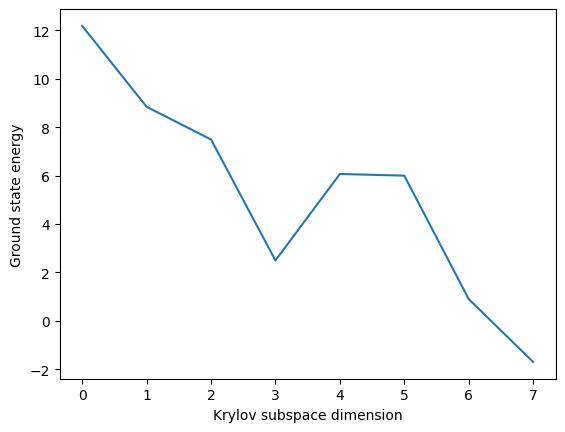

In [1078]:
GSEs, vecs, V_eps = E_vs_D(H_tilde, S_tilde, 1e-6)
plt.plot(GSEs)
plt.xlabel("Krylov subspace dimension")
plt.ylabel("Ground state energy")

## Run in batch with 10000 shots, XY4, optimization level 2, (1,1.3,1.6) folding factors and linear extrap.

In [1079]:
jobs = service.jobs(session_id="czr7a5rkzhn0008c0xq0")
job_ids = [job.job_id() for job in jobs]
est_job_results = [job.result() for job in jobs[::-1]]

t_steps = 8
H_tilde = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde = np.zeros([t_steps, t_steps], dtype=complex)
for i in range(t_steps):
    for j in range(t_steps):
        if circuits[i][j] is not None:
            H_tilde[i, j] = (
                est_job_results[i][j].data.evs[0]
                + 1j * est_job_results[i][j].data.evs[1]
            )
            S_tilde[i, j] = (
                est_job_results[i][j].data.evs[2]
                + 1j * est_job_results[i][j].data.evs[3]
            )
        else:
            H_tilde[i, j] = (
                est_job_results[i][j].data.evs[0]
                - 1j * est_job_results[i][j].data.evs[1]
            )
            S_tilde[i, j] = (
                est_job_results[i][j].data.evs[2]
                - 1j * est_job_results[i][j].data.evs[3]
            )

In [1080]:
from sympy import Matrix
Matrix(S_tilde)

Matrix([
[  0.953158339970789 + 0.0947612895073486*I,    0.665893293634491 + 0.581737121770195*I,    0.3053946329353 + 0.759130839598226*I,  -0.108194549878596 + 0.571668294944044*I,  -0.232064050519793 + 0.201332431013061*I, -0.0971440195359657 + 0.0812322464983302*I, -0.0614021565230293 + 0.0216668478371284*I,  0.00194046906195577 + 0.0226891059115825*I],
[   0.804238563415732 - 0.611738876208119*I,    0.994997980908715 + 0.131164378754216*I,  0.738623313615669 + 0.464791301871709*I,   0.152845368726734 + 0.682667952101952*I,  -0.158651744720733 + 0.556780800263915*I,   -0.165370523424126 + 0.169098442026487*I,  -0.163637519481966 + 0.0756018479726915*I, -0.0788077115881613 + 0.00513207425484021*I],
[   0.316677133007206 - 0.673537423797873*I,     0.779341530828235 - 0.49748456845997*I, 1.02557640511414 + 0.00854207850156545*I,   0.874986751952349 + 0.654651914644384*I,   0.165293495062672 + 0.693165850019196*I,  -0.0842744749641216 + 0.537991155535027*I,   -0.155024551212256 + 0.214

In [1081]:
Matrix(H_tilde)

Matrix([
[   11.1780778744561 + 0.680853362027452*I,      7.76664329826289 + 3.3666041237336*I,    4.02225775041052 + 6.13587388784123*I,  1.57884184616377 + 4.84895169966274*I, 0.517864698123137 + 3.09448581245617*I, -0.335942081651965 + 1.83183365665482*I, -0.0818240862386114 + 0.520452508764095*I, 0.0812494360350599 + 0.365566112556359*I],
[    9.42963730137573 - 5.77893886482882*I,     10.1190425332014 + 1.54175310249274*I,    8.53567293705227 + 3.18398686606552*I,  4.18134220432262 + 4.63333403460877*I,  1.29881059472104 + 4.19773627829324*I,  0.100756438932922 + 2.97222410582541*I,    -1.13899428584666 + 1.33192212404129*I,  -0.747515619635153 + 0.81712387658634*I],
[    4.74678888774978 - 5.55239724071548*I,     7.33001383371921 - 2.86071764179177*I,   8.94738217833663 + 0.635830011815837*I,  7.88532539386311 + 3.47716404582366*I,    4.49335762995696 + 3.942654711656*I,   1.53525276174159 + 3.40403294087257*I,    0.630556395210561 + 2.68716358132256*I,   -0.19438281456622 + 1.28

(11.682950858018357-0.44718501497077046j)
(10.272870691786025+1.5078314440597933j)
(6.559664775147909+0.5805939807612208j)
(-38.57410170454245+34.520501694155904j)
(-37.992429697322166-10.537796445337507j)
(-4.770778842511082-15.469142272076938j)
(-2.6178574868883264-1.0768803925550579j)
(-4.293070037036969+53.452918745693026j)


/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Ground state energy')

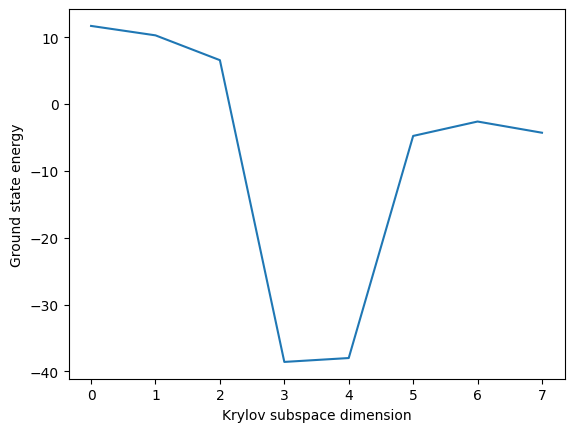

In [1082]:
def truncation(threshold, S):
    eigvals, eigvecs = np.linalg.eig(S)
    idx = eigvals.argsort()[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    D = len(eigvals)
    truncated_eigvals = []
    truncated_eigvecs = []
    # make truncated matrix whose rows are eigenvectors of S with eigval above threshold
    for i in range(D):
        if eigvals[i] >= threshold:
            truncated_eigvals.append(eigvals[i])
            truncated_eigvecs.append(eigvecs[i])
    truncated_eigvals = np.array(truncated_eigvals)
    truncated_eigvecs = np.array(truncated_eigvecs).T
    return truncated_eigvecs


def E_vs_D(H_tilde, S_tilde, threshold_slope):
    GSEs = []
    ground_states = []
    for d in range(1, len(S_tilde) + 1):
        epsilon = threshold_slope * d
        H_temp = H_tilde[0:d, 0:d]
        S_temp = S_tilde[0:d, 0:d]
        V_eps= truncation(epsilon, S_temp)
        # solve GEVP
        A = V_eps.conj().T @ H_temp @ V_eps
        B = V_eps.conj().T @ S_temp @ V_eps
        E, c = scipy.linalg.eig(a=A, b=B)
        idx = E.argsort()[::-1]
        eigvals = E[idx]
        eigvecs = c[:, idx]
        GSEs.append(eigvals[-1])
        ground_states.append(eigvecs[:, -1])
        print(min(eigvals))
    return GSEs, ground_states, V_eps


GSEs, vecs, V_eps = E_vs_D(H_tilde, S_tilde, 1e-8)
plt.plot(GSEs)
plt.xlabel("Krylov subspace dimension")
plt.ylabel("Ground state energy")

## Run on simulator for comparison

In [ ]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.primitives import StatevectorEstimator
from qiskit_aer.primitives import EstimatorV2

t_steps = 8
n_qubits = 20
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
H_tilde_sim = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde_sim = np.zeros([t_steps, t_steps], dtype=complex)
delta_t = np.pi / 40
synth = LieTrotter(reps=1)

edge_list = [(x, x + 1) for x in range(n_qubits - 1)]
edge_list.append((n_qubits - 1, 0))  # complete a loop

H = Heisenberg(1, n_qubits, edge_list)

Rxyz_circ = QuantumCircuit(2)
Rxyz_circ.rxx(2 * delta_t, 0, 1)
Rxyz_circ.ryy(2 * delta_t, 0, 1)
Rxyz_circ.rzz(2 * delta_t, 0, 1)
Rxyz_instr = Rxyz_circ.to_instruction(label="RXX+YY+ZZ")
qc_temp = QuantumCircuit(num_qubits)
for edge in edge_list:
    qc_temp.append(Rxyz_instr, edge)
time_evol = QuantumCircuit(num_qubits).compose(qc_temp)
# time_evol=PauliEvolutionGate(H,time=delta_t,synthesis=synth)

real_obs_H = SparsePauliOp("X", 1) ^ H
imag_obs_H = SparsePauliOp("Y", 1) ^ H
real_obs_S = SparsePauliOp("X", 1) ^ SparsePauliOp("I" * n_qubits, 1)
imag_obs_S = SparsePauliOp("Y", 1) ^ SparsePauliOp("I" * n_qubits, 1)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(21)
        qc.h(20)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(20))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(20))
        circuits[i][j] = qc.copy()


simulator = EstimatorV2(options={"backend_options": {"method": "matrix_product_state"}})
sim_jobs = []
for i in range(t_steps):
    for j in range(t_steps):
        if circuits[i][j] is not None:
            sim_job = simulator.run(
                [
                    (
                        circuits[i][j].decompose(reps=2),
                        [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S],
                    )
                ]
            )
            H_tilde_sim[i, j] = (
                sim_job.result()[0].data.evs[0] + 1j * sim_job.result()[0].data.evs[1]
            )
            S_tilde_sim[i, j] = (
                sim_job.result()[0].data.evs[2] + 1j * sim_job.result()[0].data.evs[3]
            )
        else:
            sim_job = simulator.run(
                [
                    (
                        circuits[j][i].decompose(reps=2),
                        [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S],
                    )
                ]
            )
            H_tilde_sim[i, j] = (
                sim_job.result()[0].data.evs[0] - 1j * sim_job.result()[0].data.evs[1]
            )
            S_tilde_sim[i, j] = (
                sim_job.result()[0].data.evs[2] - 1j * sim_job.result()[0].data.evs[3]
            )

In [1004]:
Matrix(H_tilde_sim)

Matrix([
[            12.0 + 1.25507001486316e-30*I,      9.93706441728609 + 5.7474626064001*I,       5.0496629040059 + 8.6595806636057*I,    0.178785235187916 + 7.92366026949704*I,    -2.47385287547838 + 5.00474243988688*I,     -2.6619755557205 + 2.11307042409293*I,   -1.59910651333561 + 0.493072014881873*I, -0.514042500581579 + 0.0165261463157927*I],
[     9.93706441728609 - 5.7474626064001*I, 11.9999999991619 + 1.04036295344396e-30*I,     9.93706441311714 + 5.74746260322662*I,      5.04966289963699 + 8.6595806464695*I,    0.178785250959321 + 7.92366023085031*I,     -2.47385280862397 + 5.0047424007237*I,    -2.66197544214387 + 2.11307043825277*I,   -1.59910642165576 + 0.493072104841158*I],
[      5.0496629040059 - 8.6595806636057*I,     9.93706441311714 - 5.74746260322662*I, 11.9999999667408 + 1.02599947916519e-30*I,     9.93706432391662 + 5.74746253526942*I,      5.0496628264079 + 8.65958037721626*I,     0.17878545839297 + 7.92365972364297*I,     -2.4738520474309 + 5.00474195511513*

In [1005]:
Matrix(S_tilde_sim)

Matrix([
[               1.0 + 1.04589167905263e-31*I,     0.769905377185947 + 0.559368999065584*I,      0.25248314518855 + 0.777063219428386*I,  -0.193046680384408 + 0.594136590050846*I,  -0.334720593796925 + 0.243188746370787*I, -0.223758743457612 - 1.59667280228433e-11*I,  -0.0689379141371373 - 0.0500863264823175*I,  -0.0039098560341789 - 0.0120333007952259*I],
[    0.769905377185947 - 0.559368999065584*I,                1.0 + 8.62816615085482e-32*I,     0.769905377184402 + 0.559368999064624*I,   0.252483145179771 + 0.777063219411527*I,  -0.193046680384151 + 0.594136590046354*I,       -0.33472059378838 + 0.2431887463654*I, -0.223758743449569 - 7.75986557624691e-12*I,  -0.0689379141391305 - 0.0500863264944319*I],
[     0.25248314518855 - 0.777063219428386*I,     0.769905377184402 - 0.559368999064624*I,   1.00000000000001 + 8.32001735975286e-32*I,   0.769905377191556 + 0.559368999069836*I,   0.252483145181256 + 0.777063219418545*I,    -0.193046680365919 + 0.594136590044046*I,    -0.33

(12-3.503246160812043e-46j)
(8.145919189073679+4.972366297955328e-15j)
(6.21535043173417+1.1530631641618915e-13j)
(5.484555855626748-1.5498451773908375e-12j)
(5.100524438947608+4.496626568060776e-12j)
(5.114008733977813+4.594842647260859e-12j)
(4.903756645464661-2.0579752322134853e-11j)
(4.910002775597061-3.3224415015815162e-12j)


/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Ground state energy')

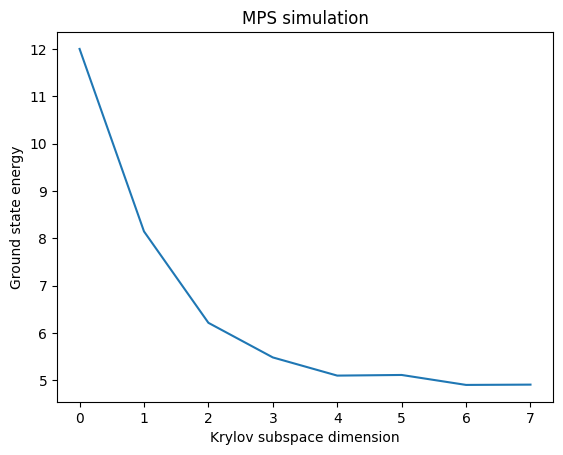

In [1006]:
GSEs, vecs, V_eps = E_vs_D(H_tilde_sim, S_tilde_sim, 1e-8)
plt.plot(GSEs)  # Ground-state energies
plt.title("MPS simulation")
plt.xlabel("Krylov subspace dimension")
plt.ylabel("Ground state energy")

## Exact diagonalisation for comparison

In [759]:
# Method from Krylov tutorial
import itertools as it
import scipy as sp
from qiskit.quantum_info import Pauli


def n_particle_gs(H_op, n_qubits, n_exc):
    """
    Find the ground state of the n particle(excitation) sector
    """
    H_x = []
    for p, coeff in H_op.to_list():
        H_x.append(set([i for i, v in enumerate(Pauli(p).x) if v]))

    H_z = []
    for p, coeff in H_op.to_list():
        H_z.append(set([i for i, v in enumerate(Pauli(p).z) if v]))

    H_c = H_op.coeffs

    n_exc = n_exc
    sub_dimn = int(sp.special.comb(n_qubits, n_exc))
    print("n_exc", n_exc, ", subspace dimension", sub_dimn)

    n_particle_H = np.zeros((sub_dimn, sub_dimn), dtype=complex)

    sparse_vecs = [
        set(vec) for vec in it.combinations(range(n_qubits), r=n_exc)
    ]  # list all of the possible sets of n_exc indices of 1s in n_exc-particle states
    for i, i_set in enumerate(sparse_vecs):
        for j, j_set in enumerate(sparse_vecs):
            if len(i_set.symmetric_difference(j_set)) <= 2:

                for p_x, p_z, coeff in zip(H_x, H_z, H_c):

                    if i_set.symmetric_difference(j_set) == p_x:
                        sgn = ((-1j) ** len(p_x.intersection(p_z))) * (
                            (-1) ** len(i_set.intersection(p_z))
                        )
                    else:
                        sgn = 0

                    n_particle_H[i, j] += sgn * coeff

    eige, eigv = np.linalg.eigh(n_particle_H)
    gs_en = eige[0]  # min(eige)
    gs_vec = eigv[:, 0]
    print("n_exc particle ground state energy: ", gs_en)
    return gs_en, gs_vec, n_particle_H


n_qubits = 20
edge_list = [(x, x + 1) for x in range(n_qubits - 1)]
edge_list.append((n_qubits - 1, 0))
H = Heisenberg(1, n_qubits, edge_list)
en, state, subspace_h = n_particle_gs(H, n_qubits, 2)
# print(np.linalg.norm(subspace_h,ord=2))

n_exc 2 , subspace dimension 190
n_exc particle ground state energy:  4.10910957277822
